# **Tutorial 5:** Empirical Models
`rokpy` includes an extensive set of empirical relations that are categorized based on the parameter they output. These relations are stored as `EmpiricalRelations` class in `methods.empirical_methods` module.

In following piece of codes, we apply some of these relations to estimate different properties. To do so, we first import a sample LAS file called *wellB.las*:

In [1]:
import lasio

lasfile = r".\\WellB.las"
las = lasio.read(lasfile)

# Extract required well logs from the file
depth = las.depth_m
vp_log = las.curvesdict['VP'].data
vs_log = las.curvesdict['VS'].data
rho_log = las.curvesdict['RHOB'].data
phit_log = las.curvesdict['PHIT'].data
vcly_log = las.curvesdict['VCL'].data
sw_log = las.curvesdict['SW'].data



## Example 1: Estimate Density from P-Velocity

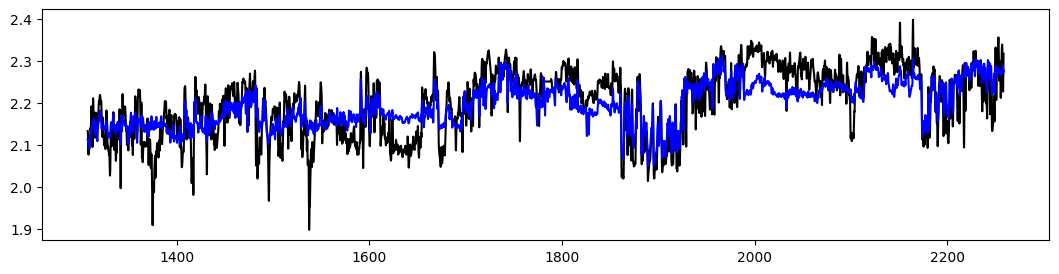

In [2]:
from rokpy.effective_medium import EmpiricalRelations
import matplotlib.pyplot as plt

vs_gardner = EmpiricalRelations.Density.FromPVelocity.gardner(vp_log, gardner_coefs = (0.28, 0.265))

plt.figure(figsize=(13,3))
plt.plot(depth, rho_log, 'k', 
         depth, vs_gardner, 'b')

## Example 2: Estimate S-Velocity from P-Velocity

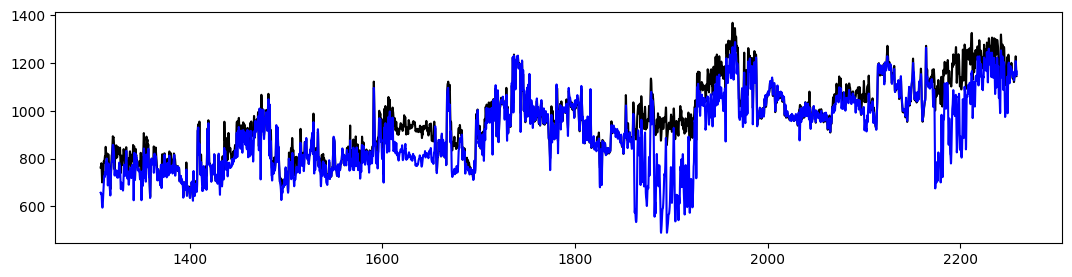

In [3]:
from rokpy.constants import CastagnaTable
from rokpy.effective_medium import EmpiricalRelations
import matplotlib.pyplot as plt

vs_castagna = EmpiricalRelations.SVelocity.FromPVelocity.castagna(vp_log, castagna_coefs = (0, 0.76, -900))

plt.figure(figsize=(13,3))
plt.plot(depth, vs_log, 'k', 
         depth, vs_castagna, 'b')

## Example 3: Estimate P-Velocity from porosity and clay volume

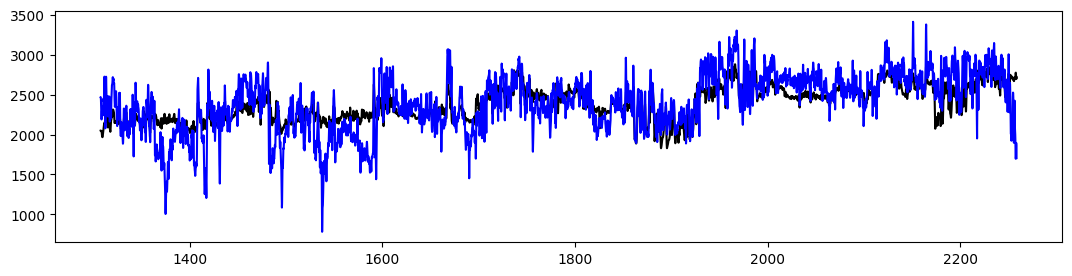

In [4]:
from rokpy.effective_medium import EmpiricalRelations
import matplotlib.pyplot as plt

vp_han = EmpiricalRelations.PVelocity.FromProperties.han(phit_log, vcly_log, han_coefs = (5500, -7560, -2080))

plt.figure(figsize=(13,3))
plt.plot(depth, vp_log, 'k', 
         depth, vp_han, 'b')

Explore `EmpiricalRelations` class to see the available relations. This class contains many useful relations.

## Example 4: Inverse of Empirical Relations
This class, in addition to standard relations like Gardner (density from P-velocity), Castagna (S-Velocity from P-Velocity), etc., also contains their reverse relation like Inverse Gardner (P-velocity from density) or Inverse Castagna (P-Velocity from S-Velocity). But note that the inverse relations still receive the standard coefficients of forward relation and they doesn't need the user to code for the corresponding inverse coefficients (It's converted internally). 

To better understand this, see the example below, where we used Castagna (to estimate S-velocity from P-velocity) and Inverse Castagna (to estimate P-velocity from S-velocity). Note that both relations receive similar sets of `coefs` while the outputs are still valid.

Text(0, 0.5, 'P-Velocity')

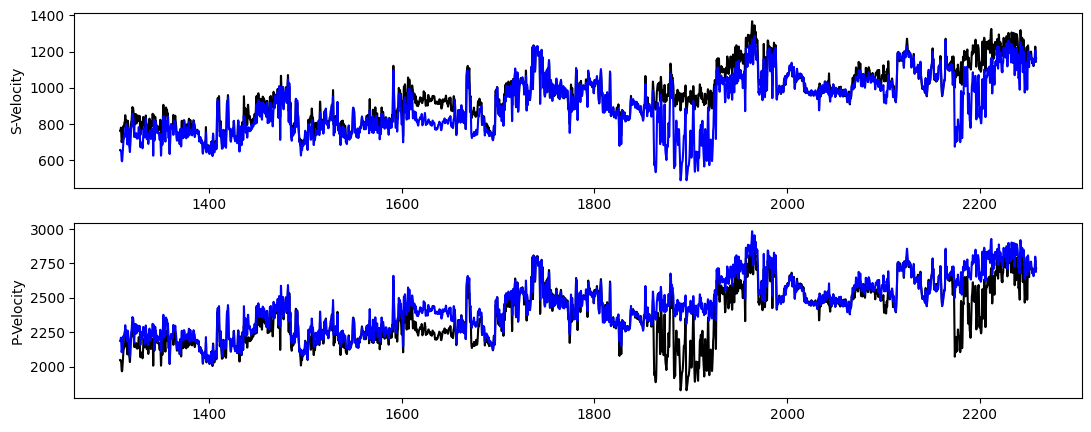

In [5]:
from rokpy.constants import CastagnaTable
from rokpy.effective_medium import EmpiricalRelations
import matplotlib.pyplot as plt

coefs = (0, 0.76, -900)
vs_castagna    = EmpiricalRelations.SVelocity.FromPVelocity.castagna(vp_log, castagna_coefs = coefs)
vp_invcastagna = EmpiricalRelations.PVelocity.FromSVelocity.castagna_inverse(vs_log, castagna_coefs = coefs)

plt.figure(figsize=(13,5))
plt1 = plt.subplot(211)
plt2 = plt.subplot(212)
plt1.plot(depth, vs_log, 'k', 
          depth, vs_castagna, 'b')
plt1.set_ylabel("S-Velocity")
plt2.plot(depth, vp_log, 'k', 
          depth, vp_invcastagna, 'b')
plt2.set_ylabel("P-Velocity")


## Tables of Standard Coefficients
Among the empirical relations there are four standard relations that receive some set of coefficients. These four relations are
1. **Gardner Relation:**    Estimate density from P-velocity
2. **Castagna Relation:**   Estimate S-velocity from P-velocity
3. **Vernik Relation:**  Estimate S-Velocity from P-Velocity
4. **Han Relation:**    Estimate P- or S-velocoty from porosity and clay-content

For each of these four relations, there exist a table of coefficients that is stored in `constants.py` module. Each table contains several set of coefficient each corresponding to a special lithology or a measurement condition. These tables are stored as classes and to be accessible, the user need to first instantiate an object of table. The user can then add or modify coefficients in the table objects.

**NOTE:** Coefficients in these table are recomputed to match the standard unit of velocity ($m/s$) and density ($g/cm^3$).

Following is an example showing how the user can access or these coefficients. 

In [6]:
from rokpy.constants import CastagnaTable, CastagnaCoefficients

# instantiate and displat the table
castagna_table = CastagnaTable()
print(f'Table of Castagna Coefficients:\n{castagna_table}\n')

# Use a set of Coeffcients in the Castagna Relation
coefs = castagna_table.SandstoneLine.coefficients
print(f'Standard Coefficients for Sandstone Line:\n{coefs}\n')
vs_castagna = EmpiricalRelations.SVelocity.FromPVelocity.castagna(vp_log, castagna_coefs = coefs)

# Modify or add some Coefficients
castagna_table.SandstoneLine.coefficients = (0, 0.76, -900)
castagna_table.add_item("BarnettShaleLine", CastagnaCoefficients(0, 0.750, -900, type="BarnettShale"))

# Display the Modified Table
print(f'Modified Table of Castagna Coefficients:\n{castagna_table}\n')

Table of Castagna Coefficients:
GeneralLine          : type: General                  	| a2: 0.0000000 	| a1: 0.500   | a0: 0.000   
LimestoneLine        : type: Limestone                	| a2: -0.0000550	| a1: 1.017   | a0: -1031.000
DolomiteLine         : type: Dolomite                 	| a2: 0.0000000 	| a1: 0.583   | a0: -78.000 
SandstoneLine        : type: Sandstone                	| a2: 0.0000000 	| a1: 0.804   | a0: -856.000
ShaleLine            : type: Shale                    	| a2: 0.0000000 	| a1: 0.770   | a0: -867.000
MudrockLine          : type: Mudrock                  	| a2: 0.0000000 	| a1: 0.862   | a0: -1172.000
HanLine              : type: Sandstone                	| a2: 0.0000000 	| a1: 0.794   | a0: -787.000
HanLine_LowClay      : type: Sandstone                	| a2: 0.0000000 	| a1: 0.754   | a0: -657.000
HanLine_HighClay     : type: Sandstone                	| a2: 0.0000000 	| a1: 0.842   | a0: -1099.000
HanLine_LowPorosity  : type: Sandstone                	|

## Empirical Models (Templates)
These models, just like the `EffectiveMedium` models are stored in `models.py` module. Generally each model refers to method or class of methods in `methods` module. Accordingly, each empirical models is a class that is wrapped around a specific empirical relation. Empirical models are designed to add some more functionalities to the empirical relations. These functionalities include fitting the coefficients, forward computation, backward computation and trend line calculation. `rokpy` includes four empirical models that are stored under `EmpiricalModels` class:
1. `GardnerModel`
2. `CastagnaModel`
3. `HanModel`
4. `VernikNodel`

Following is an exmple showing how to use these models:

Text(0.5, 1.0, 'Y = +6.32e-01 * X -5.42e+02')

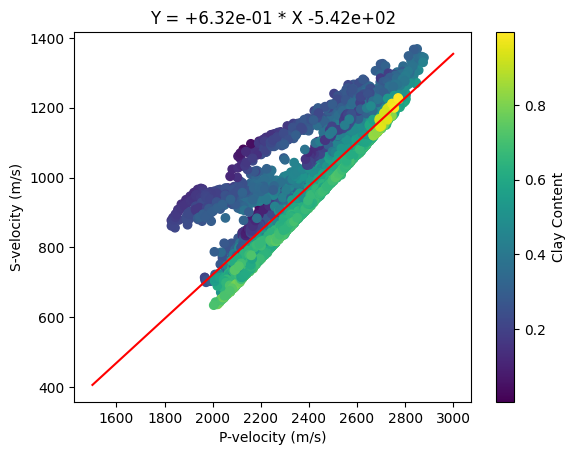

In [7]:
from rokpy.models import EmpiricalModels
from rokpy.constants import PropertyTemplates

# Optional: Define and customize PropertyTemplates (just for a better display)
properties_table = PropertyTemplates()
properties_table.PVelocity.plot_range = (1500, 3000)
properties_table.SVelocity.plot_range = ( 500, 1500)

# Define Castagna Model
castagna_model = EmpiricalModels.CastagnaModel("BarnettShale", template_table=properties_table)
castagna_model.fit_coefs(vp_log, vs_log, order=1)

# Display Data and Model
plt.scatter(vp_log, vs_log, c=vcly_log)
trend_x, trend_y = castagna_model.trend_line()
plt.plot(trend_x, trend_y, color='red')
plt.xlabel("P-velocity (m/s)")
plt.ylabel("S-velocity (m/s)")
plt.colorbar(label="Clay Content")
plt.title(str(castagna_model))


### Forward Estimate 
In the above example we defined a castagna model that relates the S-velocity to P-velocity. Using this model we can simply estimate S-velocity from a given set of P-velocities, instead of using raw mathematical Castagna relation:

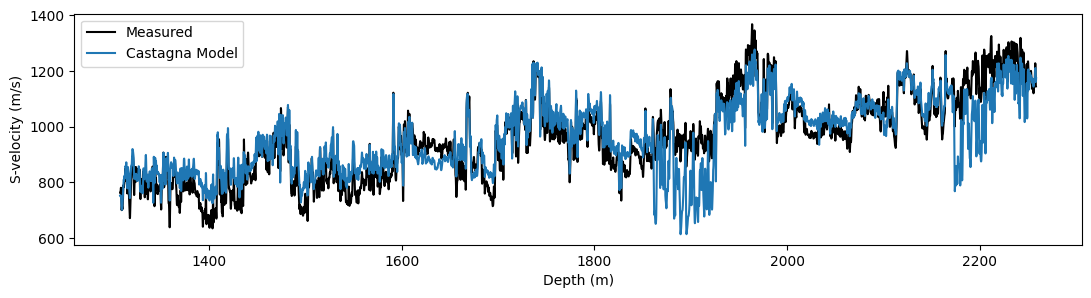

In [8]:
# Estimation is as simple as below:
vs_castagna = castagna_model.forward(vp_log)

# Display 
plt.figure(figsize=(13,3))
plt.plot(depth, vs_log, 'k', depth, vs_castagna)
plt.xlabel("Depth (m)")
plt.ylabel("S-velocity (m/s)")
plt.legend(["Measured", "Castagna Model"])

### Inverse Estimation
Users may also use a model to backward estimate the properties. e.g. in the Castagna model, the backward relation estimate P-velocity from S-velocity:

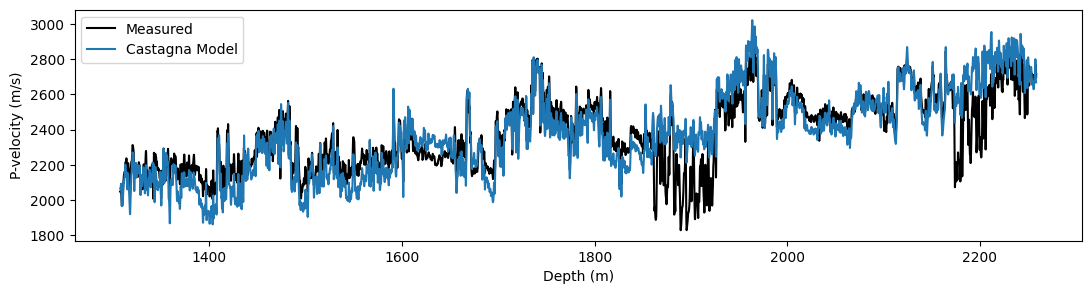

In [9]:
vp_castagna = castagna_model.inverse(vs_log)

# Display 
plt.figure(figsize=(13,3))
plt.plot(depth, vp_log, 'k', depth, vp_castagna)
plt.xlabel("Depth (m)")
plt.ylabel("P-velocity (m/s)")
plt.legend(["Measured", "Castagna Model"])